# Checking the report's numbers and the closure effect — `eval.py` demo

This notebook walks through `eval.py`, the assembly step of the iteration-3 evaluation. The evaluation is read-only, costs $0 and runs on CPU only. It checks five iteration-2 artifacts from a study of **how scientific concepts emerge and spread in an evolving OpenAlex knowledge network**.

`eval.py` runs three parts, then merges their outputs into one `eval_out.json` (`exp_eval_sol_out` schema: `metrics_agg` plus 6 datasets):

| Part | Module | What it produces |
|---|---|---|
| 1. Numbers of record | `part1_record.py` | 406 report numbers, 182 of them recomputed from item- or row-level files. Each carries a drift flag against the current report (42 flags are not OK). |
| 2. R1a turnover pre-check | `part2_r1a.py` | Is the E_up **closure** effect just neighbourhood turnover? Residualised event study, within-concept correlations, IVW pooling and controls. *This is a pre-check on data that was already screened, not a confirmation.* |
| 3. Rules and tables | `part3_rules.py` | Decision rules (a) to (d), the aligned MeSH/main block table, the held-out seal audit and the coverage table |

**Demo scope.** Parts 1 to 3 read many large iteration-2 files, which are not shipped with this notebook. `mini_demo_data.json` instead holds their **saved outputs**: a 100-row curated subset of the record (all 42 non-OK flags, the headline rows and a spread of OK and missing rows), the full R1a results, the rules, the audit and the two tables. The notebook then runs the code from `eval.py`'s `main()` **unchanged**, which computes the metrics, builds the datasets and writes `eval_out.json`. It also re-derives the aligned-block IVW pooling with the original `ivw()` helper from `common.py`.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (at Colab's versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
from __future__ import annotations

# ---- original eval.py / common.py imports
import hashlib
import json
import math
import os
import sys
import time
from pathlib import Path

import numpy as np
from loguru import logger

# ---- extra imports for the notebook (part-3 tables are DataFrames; plots at the end)
from types import SimpleNamespace
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-3/evaluation-1/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("record rows in demo subset:", len(data["record_rows"]), "| R1a event specs:", len(data["r1a"]["event"]),
      "| aligned rows:", len(data["p3"]["aligned"]), "| coverage rows:", len(data["p3"]["coverage"]))

Saved outputs of the three evaluation parts (record_of_numbers subset, R1a results, decision rules, held-out audit, aligned-block and coverage tables) that eval.py assembles into eval_out.json. Paths are relative to the run root.
record rows in demo subset: 100 | R1a event specs: 22 | aligned rows: 9 | coverage rows: 8


## Configuration

`eval.py` has no iteration or sample-size parameters, because it only assembles results. The two settings below control the demo:

- `MAX_RECORD_ROWS` is the number of numbers-of-record rows that go into the `numbers_of_record` dataset. The original uses all 406. The demo file ships a curated subset of 100.
- `RECHECK_IVW` re-runs the fixed-effect IVW pooling of `common.ivw()` on the aligned-block table and compares it with the stored values.

Neither setting changes `metrics_agg`. The record summary counts (406 rows, 42 flags) come from the full run's `record_summary.json`.

In [5]:
MAX_RECORD_ROWS = 100   # original: all 406 rows (the demo file ships a curated 100-row subset)
RECHECK_IVW = True      # re-derive aligned-block IVW / Cochran Q from the stored S and CI columns

## Shared helpers from `common.py`

`eval.py` does `import common as K`. The helpers it uses are copied here verbatim (`HEADER`, `ART_IDS`, `clean`, `dump`, `ivw`) and bundled in a `K` namespace, so the rest of the code keeps its `K.` calls. The local output folder `WS` replaces the original workspace path, and logging goes to stdout only.

In [6]:
WS = Path(".")
HEADER = "PRE-CHECK ON ALREADY-SCREENED DATA; NOT CONFIRMATION; E_up promoted post hoc"
ART_IDS = {"exp_1": "art_BdBvbNuNU8E7", "exp_2": "art_yjFB8Spw2w6M", "exp_3": "art_mbFjmo5rbbf8",
           "exp_4": "art_yWUkgWWKyq_h", "dataset_5": "art_eR1Z7fMlOcxs"}


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")


def clean(x):
    """JSON-safe conversion (NaN/inf -> None, numpy -> python)."""
    if isinstance(x, dict):
        return {str(k): clean(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [clean(v) for v in x]
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating, float)):
        v = float(x)
        return None if not math.isfinite(v) else v
    if isinstance(x, np.bool_):
        return bool(x)
    if isinstance(x, np.ndarray):
        return clean(x.tolist())
    return x


def dump(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(clean(obj), indent=1, allow_nan=False))


# ------------------------------------------------------------------ meta-analysis helpers
def ivw(y: list[float], se: list[float]) -> dict:
    """Fixed-effect inverse-variance pooling, Cochran Q, I^2 with Q-profile CI (k small => very imprecise)."""
    from scipy import optimize, stats
    y, se = np.asarray(y, float), np.asarray(se, float)
    w = 1 / se ** 2
    mu = float((w * y).sum() / w.sum())
    se_mu = float(1 / math.sqrt(w.sum()))
    Q = float((w * (y - mu) ** 2).sum())
    k = len(y)
    df = k - 1
    pQ = float(stats.chi2.sf(Q, df)) if df > 0 else float("nan")
    I2 = max(0.0, (Q - df) / Q) if Q > 0 else 0.0
    s2 = df * w.sum() / (w.sum() ** 2 - (w ** 2).sum())  # Higgins-Thompson typical within-study variance

    def qgen(t2: float) -> float:
        ww = 1 / (se ** 2 + t2)
        m = (ww * y).sum() / ww.sum()
        return float((ww * (y - m) ** 2).sum())

    def solve(target: float) -> float:
        if qgen(0.0) <= target:
            return 0.0
        hi = 1.0
        while qgen(hi) > target:
            hi *= 10
            if hi > 1e8:
                return float("nan")
        return float(optimize.brentq(lambda t: qgen(t) - target, 0.0, hi))

    t2_lo = solve(stats.chi2.ppf(0.975, df))
    t2_hi = solve(stats.chi2.ppf(0.025, df))
    i2 = lambda t: t / (t + s2) if np.isfinite(t) else float("nan")  # noqa: E731
    return dict(k=k, S_ivw=mu, se_ivw=se_mu, ci=[mu - 1.96 * se_mu, mu + 1.96 * se_mu],
                z=mu / se_mu, p=float(2 * stats.norm.sf(abs(mu / se_mu))), Q=Q, df=df, p_Q=pQ, I2=I2,
                I2_ci_qprofile=[i2(t2_lo), i2(t2_hi)], tau2_ci_qprofile=[t2_lo, t2_hi],
                note="Cochran Q has very low power at k = 2; a non-significant Q is NOT evidence of homogeneity; "
                     "I^2 CI via Q-profile tau^2 bounds mapped with the Higgins-Thompson typical variance.")


K = SimpleNamespace(WS=WS, HEADER=HEADER, ART_IDS=ART_IDS, setup_logging=setup_logging, clean=clean, dump=dump, ivw=ivw)

## `eval.py` helpers: `num` and `evals`

The `exp_eval_sol_out` schema requires every `eval_*` field to be a number. `num()` turns a value into a finite float or returns `None`. `evals()` keeps the numeric fields only, turns booleans into 0/1 and adds the `eval_` prefix to each key.

In [7]:
def num(x) -> float | None:
    try:
        v = float(x)
    except (TypeError, ValueError):
        return None
    return v if math.isfinite(v) else None


def evals(d: dict) -> dict:
    """eval_* fields must be numbers: keep finite numerics only (bools -> 0/1)."""
    out = {}
    for k, v in d.items():
        if isinstance(v, bool):
            out[f"eval_{k}"] = int(v)
        else:
            n = num(v)
            if n is not None:
                out[f"eval_{k}"] = n
    return out

## Run the three parts (loaded here from their saved outputs)

In `eval.py` this step reads:

```python
r1a = part2_r1a.main()          # R1a turnover pre-check        -> results/r1a/r1a_results.json
rec_sum = part1_record.main()   # numbers of record             -> results/record_of_numbers.json, record_summary.json
p3 = part3_rules.main()         # dict(aligned=DataFrame, rules=dict, audit=dict, coverage=DataFrame)
rec = K.load_json(K.RES / "record_of_numbers.json")["rows"]
```

Those calls need the large iteration-2 files, so the demo rebuilds the same objects from `data` instead. Part 3's return value is a dict holding two pandas DataFrames, so both are rebuilt with `pd.DataFrame`. Nothing else changes.

In [8]:
K.setup_logging("eval")
t0 = time.time()
logger.info("PART 2 (R1a) ... [loaded from saved r1a_results.json]")
r1a = data["r1a"]
logger.info("PART 1 (numbers of record) ... [loaded from saved record_summary.json]")
rec_sum = data["record_summary"]
logger.info("PART 3 (rules and tables) ... [loaded from saved decision_rules / heldout_audit / aligned / coverage]")
p3 = dict(aligned=pd.DataFrame(data["p3"]["aligned"]), rules=data["p3"]["rules"], audit=data["p3"]["audit"],
          coverage=pd.DataFrame(data["p3"]["coverage"]))
rec = data["record_rows"][:MAX_RECORD_ROWS]

logger.info(f"R1a verdicts: { {k: v['verdict'] for k, v in r1a['verdicts'].items()} }")
logger.info(f"record: {rec_sum['n_rows']} rows ({rec_sum['n_recomputed']} recomputed), {rec_sum['n_flags']} non-OK flags; demo rows used: {len(rec)}")

12:31:59|INFO   |PART 2 (R1a) ... [loaded from saved r1a_results.json]


12:31:59|INFO   |PART 1 (numbers of record) ... [loaded from saved record_summary.json]


12:31:59|INFO   |PART 3 (rules and tables) ... [loaded from saved decision_rules / heldout_audit / aligned / coverage]


12:31:59|INFO   |R1a verdicts: {'main': 'AMBIGUOUS / UNDERPOWERED', 'mesh': 'AMBIGUOUS / UNDERPOWERED', 'pooled': 'AMBIGUOUS / UNDERPOWERED'}


12:31:59|INFO   |record: 406 rows (182 recomputed), 42 non-OK flags; demo rows used: 100


### Optional check: re-derive the aligned-block IVW pooling

Part 3 pools each aligned (label × indicator) row's MeSH and main closure estimates with fixed-effect inverse-variance weighting, using **SE = CI width / 3.92**. This is the method of the side-by-side file. The cell below runs the same `K.ivw` call on the stored S and CI columns and checks that it reproduces `S_ivw_ciwidth_se` and `Q_ciwidth_se` (and hence the file's values). Only 5 of the 9 rows are interpretable. With k = 2, Cochran Q has almost no power.

In [9]:
if RECHECK_IVW:
    chk = []
    for r in p3["aligned"].itertuples():
        # the same call as part3_rules.aligned_block(): SE = CI width / 3.92 for both populations
        ivc = K.ivw([r.S_mesh, r.S_main], [(r.ci_hi_mesh - r.ci_lo_mesh) / 3.92, (r.ci_hi_main - r.ci_lo_main) / 3.92])
        chk.append(dict(label=r.label, indicator=r.indicator, S_ivw=ivc["S_ivw"], S_ivw_stored=r.S_ivw_ciwidth_se, Q=ivc["Q"],
                        Q_stored=r.Q_ciwidth_se, matches=bool(abs(ivc["S_ivw"] - r.S_ivw_ciwidth_se) < 1e-9 and abs(ivc["Q"] - r.Q_ciwidth_se) < 1e-6),
                        interpretable=r.interpretable))
    chk = pd.DataFrame(chk)
    print(chk.round(4).to_string(index=False))
    print(f"\n{chk.matches.sum()} / {len(chk)} aligned rows re-derived exactly")

label           indicator   S_ivw  S_ivw_stored       Q  Q_stored  matches  interpretable
    E accretion_shift_rar -0.0433       -0.0433 12.6807   12.6807     True          False
    E             closure -0.6240       -0.6240  3.9698    3.9698     True          False
    E               P_rar -0.0169       -0.0169  2.3562    2.3562     True          False
E_alt accretion_shift_rar  0.0270        0.0270  3.2350    3.2350     True          False
E_alt             closure -0.0773       -0.0773  1.9399    1.9399     True           True
E_alt               P_rar  0.0263        0.0263  0.7322    0.7322     True           True
 E_up accretion_shift_rar  0.0277        0.0277 11.4209   11.4209     True           True
 E_up             closure -0.4104       -0.4104  6.1599    6.1599     True           True
 E_up               P_rar  0.0145        0.0145  0.5347    0.5347     True           True

9 / 9 aligned rows re-derived exactly


## Aggregate metrics (`metrics_agg`)

This is the code from `eval.py` without changes. It collects the headline numbers:

- **Record** flag counts. **Classifier** P, R, accuracy, F1, AUC and kappa at t_F1 0.5073, against the predict-all-positive baseline (F1 0.715). **Prediction** ΔAUC for logit and HGB.
- For each population (`main`, `mesh`), the **R1a** values from primary spec P: S_raw, S_raw_cc, the residualised S_res with its CI, the retained fraction, the MDE, the gate and verdict flags, the volume-only and rarefied specs, and the controls. It also adds the within-concept correlations of closure with each turnover measure.
- The **IVW pooled** residualised effect, Q and I², the pooled retained fraction and the main placebo.
- The **rules** (a) to (d), the held-out seal audit, and the aligned and coverage table counts.

In [10]:
rules = p3["rules"]
audit = p3["audit"]
byid = {r["id"]: r for r in rec}
ev = {(r["population"], r["spec"]): r for r in r1a["event"]}
corr = {(c["population"], c["pair"]): c for c in r1a["correlations"]}

def rv(i: str) -> float | None:
    return num(byid[i]["value"]) if i in byid else None

m = dict(record_n_rows=rec_sum["n_rows"], record_n_recomputed=rec_sum["n_recomputed"], record_n_not_rederivable=rec_sum["n_not_rederivable"],
         record_n_flags=rec_sum["n_flags"])
for f, c in rec_sum["n_flags_by_type"].items():
    m[f"record_n_flag_{f}"] = c
m.update(classifier_precision=rv("B1.clf.tF1.precision"), classifier_recall=rv("B1.clf.tF1.recall"), classifier_accuracy=rv("B1.clf.tF1.accuracy"),
         classifier_f1=rv("B1.clf.tF1.f1"), classifier_auc=rv("B1.clf.auc"), classifier_kappa=rv("B1.clf.tF1.kappa"),
         majority_all_positive_f1=rv("B1.base.all_positive_f1"), classifier_f1_minus_all_positive=rv("B1.clf.delta_f1_vs_allpos"),
         classifier_minus_llmA_f1=rv("B1.clf_minus_llmA.f1"), classifier_minus_llmB_f1=rv("B1.clf_minus_llmB.f1"),
         main_E_up_logit_delta_auc=rv("B3.E_up.logit.delta_auc"), main_E_up_hgb_delta_auc=rv("B3.E_up.hgb.delta_auc"))
for pop in ("main", "mesh"):
    r = ev[(pop, "P")]
    m.update({f"{pop}_S_raw": r["S_raw"], f"{pop}_S_raw_cc": r["S_raw_cc"], f"{pop}_S_res": r["S_res"], f"{pop}_S_res_ci_lo": r["S_res_ci"][0],
              f"{pop}_S_res_ci_hi": r["S_res_ci"][1], f"{pop}_S_fit": r["S_fit"], f"{pop}_retained": r["retained"],
              f"{pop}_retained_ci_lo": r["retained_ci"][0], f"{pop}_retained_ci_hi": r["retained_ci"][1], f"{pop}_mde_res_sd": r["mde_res_in_sd"],
              f"{pop}_n_treated_res": r["n_treated_res"], f"{pop}_gate_S_exact": int(r1a["gate"][pop]["S_exact"]),
              f"{pop}_gate_passed": int(r1a["gate"][pop]["passed"]),
              f"{pop}_verdict_not_reducible": int(r1a["verdicts"][pop]["verdict"].startswith("NOT REDUCIBLE")),
              f"{pop}_verdict_largely_turnover": int(r1a["verdicts"][pop]["verdict"].startswith("LARGELY")),
              f"{pop}_retained_volume_only_V0": ev[(pop, "V0")]["retained"], f"{pop}_retained_spec_R_rarefied": ev[(pop, "R")]["retained"],
              f"{pop}_neg_control_retained_vs_V0": r1a["controls"][pop]["NEG"]["retained_vs_V0"],
              f"{pop}_pos_oracle_retained": r1a["controls"][pop]["POS_ORACLE"]["retained"],
              f"{pop}_pos_closure_raw_retained": r1a["controls"][pop]["POS"]["retained"]})
    for key in ("new_rel", "novelty", "beta_sim", "beta_sim_rar"):
        c = corr[(pop, f"closure~{key}")]
        m[f"{pop}_r_within_closure_{key}"] = c.get("r_within")
        m[f"{pop}_r_within_closure_{key}_ci_lo"] = c.get("r_within_ci", [None, None])[0]
        m[f"{pop}_r_within_closure_{key}_ci_hi"] = c.get("r_within_ci", [None, None])[1]
pr = r1a["pooling"]
m.update(ivw_S_res=pr["P"]["res"]["S_ivw"], ivw_se_res=pr["P"]["res"]["se_ivw"], ivw_S_res_ci_lo=pr["P"]["res"]["ci"][0],
         ivw_S_res_ci_hi=pr["P"]["res"]["ci"][1], Q_res=pr["P"]["res"]["Q"], p_Q_res=pr["P"]["res"]["p_Q"], I2_res=pr["P"]["res"]["I2"],
         ivw_S_raw_cc=pr["P"]["raw_cc"]["S_ivw"], Q_raw_cc=pr["P"]["raw_cc"]["Q"], ivw_S_raw_recorded=pr["raw_recorded_files"]["S_ivw"],
         Q_raw_recorded=pr["raw_recorded_files"]["Q"], pooled_retained=pr["pooled_verdict"]["retained"],
         pooled_retained_ci_lo=pr["pooled_verdict"]["retained_ci"][0], pooled_retained_ci_hi=pr["pooled_verdict"]["retained_ci"][1],
         main_placebo_S_res=r1a["controls"]["main"]["PLACEBO"]["S_res"],
         rule_a_triggered=int(rules["a"]["triggered"]), rule_b_pilot_only=int(rules["b"]["pilot_only"]), rule_c_met=int(rules["c"]["met"]),
         rule_d_sealed=int(rules["d"]["sealed"]), heldout_id_hits_exp3_exp4=audit["hits_exp3_exp4_total"],
         heldout_files_scanned=audit["files_scanned_exp3_exp4"], heldout_ids_dataset5=audit["id_sets"]["n_heldout_dataset5"],
         heldout_iter1_subset=int(audit["id_sets"]["iter1_subset_of_dataset5"]),
         aligned_n_interpretable=int(p3["aligned"].interpretable.sum()), aligned_n_file_reproduced=int(p3["aligned"].ivw_agrees_file.sum()),
         coverage_n_done=int((p3["coverage"].status == "done").sum()), coverage_n_partial=int((p3["coverage"].status == "partial").sum()),
         coverage_n_planned=int((p3["coverage"].status == "planned").sum()), runtime_s=time.time() - t0)
metrics = {k: float(v) for k, v in m.items() if num(v) is not None}
print(f"{len(metrics)} metrics")

117 metrics


## Build the six datasets

This is also unchanged `eval.py` code. Each dataset turns one part's rows into `{input, output, metadata_*, eval_*}` examples:

1. `numbers_of_record`: one example per report number (its claim, recomputed value, drift flag, source path and the report's value). Hash rows use the hex digest as their output.
2. `r1a_results`: one example per (population × residualisation spec), such as P (primary), R (rarefied), V0 (volume only), POS/NEG controls and D_* single-covariate specs.
3. `r1a_within_concept_correlations`: the within-concept r of closure with each turnover measure, with its CI.
4. `aligned_block`: the MeSH vs main S, IVW and Q for each aligned row.
5. `decision_rules`: rules (a) to (d), each with its verdict and supporting numbers.
6. `coverage`: each research question or activity, scored done / partial / planned.

In [11]:
# ---------------- datasets
ds_rec = []
for r in rec:
    ex = {"input": r["claim"], "output": "" if r["value"] is None else f"{r['value']:.6g}",
          "metadata_id": r["id"], "metadata_block": r["block"], "metadata_flag": r["flag"], "metadata_unit": r["unit"],
          "metadata_estimator": r["estimator"], "metadata_source_path": r["source_path"], "metadata_source_key": r["source_key"],
          "metadata_recomputed": r["recomputed"], "metadata_recompute_method": r["recompute_method"], "metadata_note": r["note"],
          "metadata_report_line": r["report_line"], "predict_report_value": "" if r["report_value"] is None else f"{r['report_value']:g}"}
    if r.get("hash_hex"):
        ex["output"] = r["hash_hex"]
        ex["metadata_hash_match"] = r.get("hash_match")
    ex.update(evals(dict(value=r["value"], ci_lo=r["ci_lo"], ci_hi=r["ci_hi"], n=r["n"], report_value=r["report_value"],
                         agrees=r["agrees"] if r["agrees"] is not None else None, flag_ok=r["flag"] in ("OK", "MISSING_IN_REPORT"))))
    ds_rec.append(ex)
ds_r1a = []
for r in r1a["event"]:
    ex = {"input": f"R1a event study E_up closure, population={r['population']}, residualisation spec={r['spec']} ({K.HEADER})",
          "output": r["verdict_rule_applied"], "metadata_population": r["population"], "metadata_spec": r["spec"],
          "metadata_diff_k_raw": r["diff_k_raw"], "metadata_diff_k_res": r["diff_k_res"], "metadata_header": K.HEADER}
    ex.update(evals({k: r[k] for k in ("S_raw", "S_raw_cc", "S_res", "S_res_se", "S_res_p", "S_fit", "retained", "mde_res", "mde_res_in_sd",
                                       "n_treated_raw", "n_treated_res", "treated_lost", "retained_boot_dropped")}))
    ex.update(evals(dict(S_res_ci_lo=r["S_res_ci"][0], S_res_ci_hi=r["S_res_ci"][1], retained_ci_lo=r["retained_ci"][0],
                         retained_ci_hi=r["retained_ci"][1], S_fit_ci_lo=r["S_fit_ci"][0], S_fit_ci_hi=r["S_fit_ci"][1])))
    ds_r1a.append(ex)
ds_corr = []
for c in r1a["correlations"]:
    if "r_within" not in c:
        continue
    ex = {"input": f"Within-concept correlation {c['pair']} ({c['x']} vs {c['y']}), population={c['population']}",
          "output": f"{c['r_within']:.3f} [{c['r_within_ci'][0]:.3f}, {c['r_within_ci'][1]:.3f}]", "metadata_role": c["role"]}
    ex.update(evals(dict(r_within=c["r_within"], r_within_ci_lo=c["r_within_ci"][0], r_within_ci_hi=c["r_within_ci"][1],
                         rho_within=c["rho_within"], r_pooled=c["r_pooled"], n_concepts=c["n_concepts"], n_rows=c["n_rows"])))
    ds_corr.append(ex)
ds_al = []
for r in p3["aligned"].to_dict("records"):
    ex = {"input": f"Aligned block {r['label']} x {r['indicator']}: MeSH vs main S, IVW and Q",
          "output": f"S_mesh {r['S_mesh']:.3f}, S_main {r['S_main']:.3f}, IVW {r['S_ivw_ciwidth_se']:.3f}, Q {r['Q_ciwidth_se']:.2f}, "
                    f"interpretable={r['interpretable']}", "metadata_note": r["note"]}
    ex.update(evals({k: v for k, v in r.items() if k not in ("label", "indicator", "note")}))
    ds_al.append(ex)
ds_rules = []
for k in "abcd":
    rr = rules[k]
    ex = {"input": f"Decision rule ({k}): {rr.get('text') or rr.get('condition')}", "output": rr["verdict"],
          "metadata_text_status": rr["text_status"], "metadata_source": rr["source"]}
    flag = {"a": rr.get("triggered"), "b": rr.get("pilot_only"), "c": rr.get("met"), "d": rr.get("sealed")}[k]
    ex["eval_rule_outcome"] = int(bool(flag))
    if k == "a":
        ex.update(evals(dict(gate_a_share=rr["value"], graft_events_total=rr["graft_events"]["total"], graft_events_kw5=rr["graft_events"]["kw5"])))
    if k == "b":
        ex.update(evals(dict(realised_N_c=rr["realised_N_c"], mde_delta_auc_070=rr["mde_delta_auc_base070"], mde_delta_auc_080=rr["mde_delta_auc_base080"])))
    if k == "c":
        ex["metadata_per_precursor"] = rr["per_precursor"]
        ex.update(evals(dict(n_precursor_rows_all_met=sum(c["all_met"] for c in rr["per_precursor"]))))
    if k == "d":
        ex.update(evals(dict(hits_exp3_exp4=rr["hits_exp3_exp4"], files_scanned=rr["files_scanned"])))
        ex["metadata_exp2_caveat"] = rr["exp2_caveat"]
    ds_rules.append(ex)
ds_cov = []
for r in p3["coverage"].to_dict("records"):
    ds_cov.append({"input": f"Coverage of {r['item']}", "output": r["status"], "metadata_evidence": r["evidence"], "metadata_gap": r["gap"],
                   "metadata_scheduled": r["scheduled"], "eval_status_score": {"done": 1.0, "partial": 0.5, "planned": 0.0}[r["status"]]})
print({n: len(d) for n, d in [("numbers_of_record", ds_rec), ("r1a_results", ds_r1a), ("r1a_within_concept_correlations", ds_corr),
                              ("aligned_block", ds_al), ("decision_rules", ds_rules), ("coverage", ds_cov)]})

{'numbers_of_record': 100, 'r1a_results': 22, 'r1a_within_concept_correlations': 13, 'aligned_block': 9, 'decision_rules': 4, 'coverage': 8}


## Assemble and write `eval_out.json`

This is `eval.py`'s final block without changes. It adds the metadata (verdicts, rule outcomes, flag counts and caveats) to the metrics and datasets and writes `eval_out.json` to the current folder.

In [12]:
out = {
    "metadata": {
        "evaluation_name": "Fix the record and test closure vs turnover (iteration 3, gen_art_evaluation_1)",
        "description": "Part 1 numbers of record with drift flags vs iter_3/gen_strat/current_report.md; Part 2 R1a turnover pre-check on the two "
                       "already-screened populations; Part 3 decision rules (a)-(d), aligned-block table, held-out seal audit, coverage.",
        "header": K.HEADER,
        "inputs": {k: v for k, v in K.ART_IDS.items()},
        "r1a_spec_sha256": r1a["spec_sha256"],
        "r1a_verdicts": {k: v["verdict"] for k, v in r1a["verdicts"].items()},
        "rules": {k: rules[k]["verdict"] for k in "abcd"},
        "record_flag_counts": rec_sum["n_flags_by_type"],
        "notes": ["All paths are relative to the run root.", "Q is underpowered at k = 2; it is not a test of agreement.",
                  "MeSH reproduction gate: S exact, CI off by 0.025 because exp_4's shared RNG stream cannot be replayed (recorded CI lies inside the "
                  "30-seed Monte-Carlo range).", "Deviation D1: MeSH SPEC P uses beta_sim_raw (the column computed with the main-pool code); "
                  "plan-literal beta_sim is sensitivity B_native."],
    },
    "metrics_agg": metrics,
    "datasets": [dict(dataset="numbers_of_record", examples=ds_rec), dict(dataset="r1a_results", examples=ds_r1a),
                 dict(dataset="r1a_within_concept_correlations", examples=ds_corr), dict(dataset="aligned_block", examples=ds_al),
                 dict(dataset="decision_rules", examples=ds_rules), dict(dataset="coverage", examples=ds_cov)],
}
K.dump(out, K.WS / "eval_out.json")
logger.info(f"eval_out.json written: {len(metrics)} metrics, datasets {[len(d['examples']) for d in out['datasets']]}, {time.time() - t0:.0f}s")

12:32:00|INFO   |eval_out.json written: 117 metrics, datasets [100, 22, 13, 9, 4, 8], 0s


## Results

The key numbers of record, the R1a verdicts and the decision rules, followed by four plots:

1. The count of each drift-flag type across the full 406-row record.
2. The retained fraction (S_res / S_raw_cc) for each residualisation spec, by population. A value near 1 means turnover explains little of the closure effect, and a value near 0 means it explains most of it. The oracle positive control (POS_ORACLE) should be near 0. The noise negative control (NEG) adds pure noise to the volume-only spec, so its bar should match V0; it retains 1.00 (main) and 0.97 (MeSH) of the V0 effect.
3. The residualised closure effect S_res with its 95% CI for each spec, including the IVW-pooled value.
4. The within-concept correlation of closure with each turnover measure.

                                  quantity           value [95% CI]
               Classifier F1 @ t_F1 0.5073                    0.818
                            Classifier AUC                    0.888
                          Classifier kappa                    0.545
Predict-all-positive F1 (trivial baseline)                    0.715
                  E_up dAUC, primary logit                   -0.010
    E_up dAUC, HGB (what Table 18 reports)                    0.019
            main  S_raw_cc (closure, E_up)                   -0.758
       main  S_res (turnover-residualised)  -0.566  [-1.140, 0.087]
                            main  retained    0.746  [0.080, 0.895]
                            MeSH  S_raw_cc                   -0.156
                               MeSH  S_res  -0.094  [-0.387, 0.217]
                            MeSH  retained   0.604  [-1.277, 2.852]
                   IVW S_res (main + MeSH)  -0.186  [-0.453, 0.081]
             Cochran Q (k=2, underpowered)      

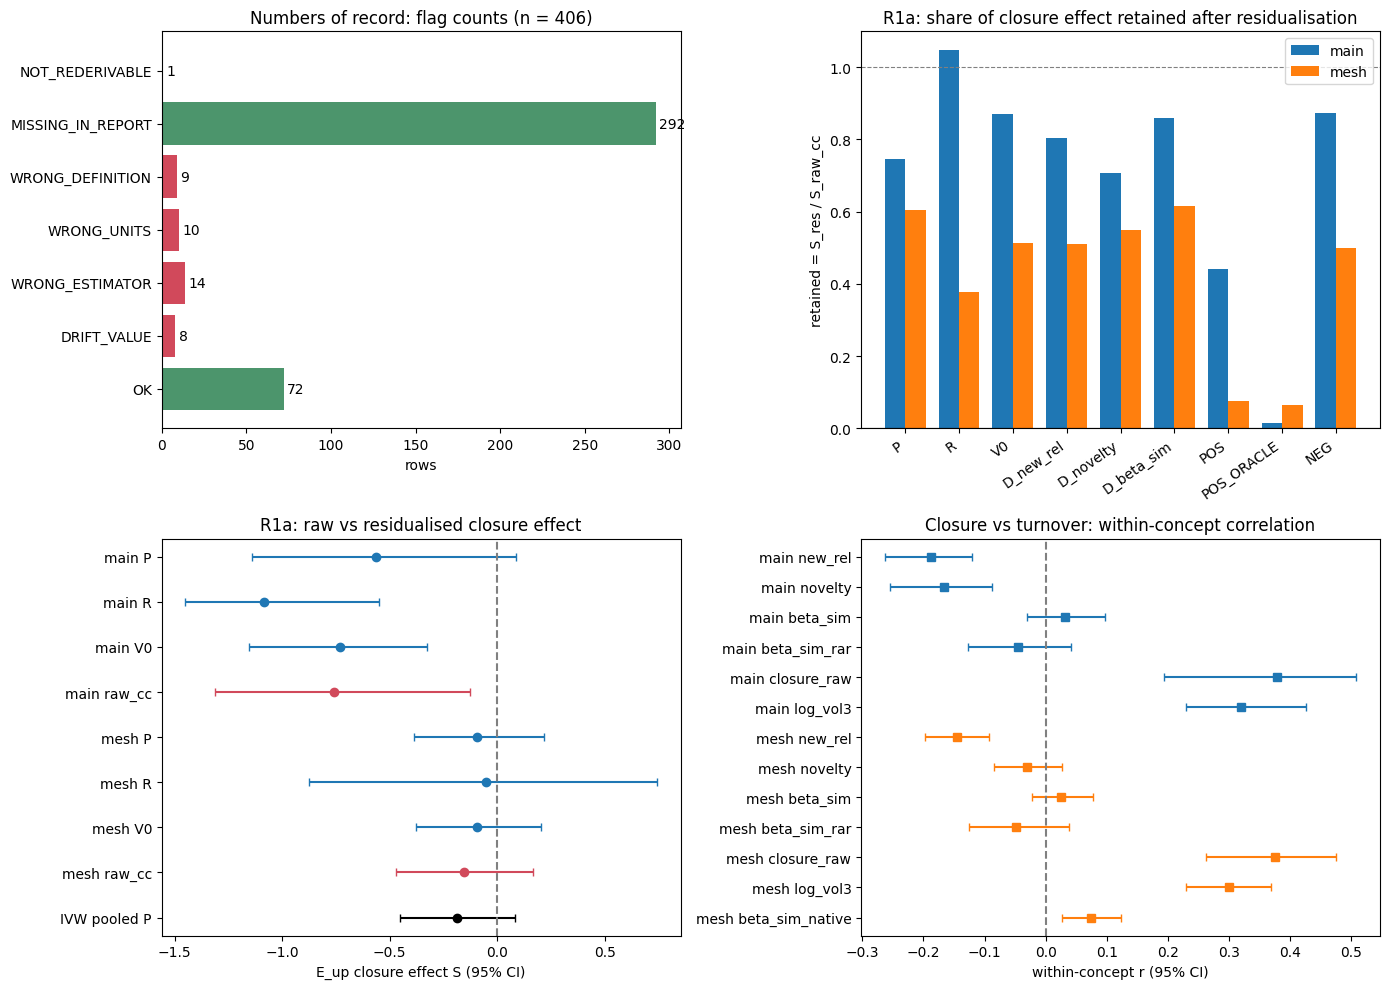

In [13]:
key = [("Classifier F1 @ t_F1 0.5073", "classifier_f1"), ("Classifier AUC", "classifier_auc"), ("Classifier kappa", "classifier_kappa"),
       ("Predict-all-positive F1 (trivial baseline)", "majority_all_positive_f1"), ("E_up dAUC, primary logit", "main_E_up_logit_delta_auc"),
       ("E_up dAUC, HGB (what Table 18 reports)", "main_E_up_hgb_delta_auc"),
       ("main  S_raw_cc (closure, E_up)", "main_S_raw_cc"), ("main  S_res (turnover-residualised)", "main_S_res"), ("main  retained", "main_retained"),
       ("MeSH  S_raw_cc", "mesh_S_raw_cc"), ("MeSH  S_res", "mesh_S_res"), ("MeSH  retained", "mesh_retained"),
       ("IVW S_res (main + MeSH)", "ivw_S_res"), ("Cochran Q (k=2, underpowered)", "Q_res"), ("I2", "I2_res"),
       ("main r_within(closure, new-relation rate)", "main_r_within_closure_new_rel"), ("main placebo S_res", "main_placebo_S_res"),
       ("Record rows / non-OK flags", None)]
rows = []
for lab, k in key:
    if k is None:
        rows.append((lab, f"{int(metrics['record_n_rows'])} / {int(metrics['record_n_flags'])}"))
    elif k not in metrics:
        rows.append((lab, "n/a (row not in the first MAX_RECORD_ROWS record rows)"))
    else:
        lo, hi = metrics.get(k + "_ci_lo"), metrics.get(k + "_ci_hi")
        rows.append((lab, f"{metrics[k]:.3f}" + (f"  [{lo:.3f}, {hi:.3f}]" if lo is not None and hi is not None else "")))
print(pd.DataFrame(rows, columns=["quantity", "value [95% CI]"]).to_string(index=False))
print("\nR1a verdicts:", out["metadata"]["r1a_verdicts"])
for k, v in out["metadata"]["rules"].items():
    print(f"rule ({k}): {v[:110]}")

flagged = pd.DataFrame([{"id": e["metadata_id"], "flag": e["metadata_flag"], "value": e["output"], "report": e["predict_report_value"]}
                        for e in ds_rec if e["metadata_flag"] not in ("OK", "MISSING_IN_REPORT")])
print(f"\nNon-OK flagged rows in the demo subset ({len(flagged)}), first 12:")
print(flagged.head(12).to_string(index=False))

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
# (1) drift flag counts (full record)
fc = {k: v for k, v in rec_sum["n_flags_by_type"].items() if v > 0}
ax[0, 0].barh(list(fc), list(fc.values()), color=["#4c956c" if k in ("OK", "MISSING_IN_REPORT") else "#d1495b" for k in fc])
for i, v in enumerate(fc.values()):
    ax[0, 0].text(v + 2, i, str(v), va="center")
ax[0, 0].set_title(f"Numbers of record: flag counts (n = {rec_sum['n_rows']})"); ax[0, 0].set_xlabel("rows")

# (2) retained fraction by spec
specs = [s for s in ("P", "R", "V0", "D_new_rel", "D_novelty", "D_beta_sim", "POS", "POS_ORACLE", "NEG")]
x = np.arange(len(specs)); w = 0.38
for j, (pop, col) in enumerate([("main", "#1f77b4"), ("mesh", "#ff7f0e")]):
    ret = [ev[(pop, s)]["retained"] if (pop, s) in ev and ev[(pop, s)]["retained"] is not None else np.nan for s in specs]
    ax[0, 1].bar(x + (j - 0.5) * w, ret, w, label=pop, color=col)
ax[0, 1].axhline(1, ls="--", c="grey", lw=0.8); ax[0, 1].axhline(0, c="k", lw=0.8)
ax[0, 1].set_xticks(x); ax[0, 1].set_xticklabels(specs, rotation=35, ha="right")
ax[0, 1].set_title("R1a: share of closure effect retained after residualisation"); ax[0, 1].legend(); ax[0, 1].set_ylabel("retained = S_res / S_raw_cc")

# (3) S_res forest plot with CIs
fr = []
for pop in ("main", "mesh"):
    for s in ("P", "R", "V0"):
        r = ev[(pop, s)]
        fr.append((f"{pop} {s}", r["S_res"], r["S_res_ci"][0], r["S_res_ci"][1]))
    fr.append((f"{pop} raw_cc", ev[(pop, 'P')]["S_raw_cc"], *ev[(pop, 'P')]["S_raw_cc_ci"]))
fr.append(("IVW pooled P", metrics["ivw_S_res"], metrics["ivw_S_res_ci_lo"], metrics["ivw_S_res_ci_hi"]))
for i, (lab, s, lo, hi) in enumerate(fr):
    ax[1, 0].errorbar(s, i, xerr=[[s - lo], [hi - s]], fmt="o", color="#d1495b" if "raw" in lab else ("k" if "IVW" in lab else "#1f77b4"), capsize=3)
ax[1, 0].axvline(0, c="grey", ls="--"); ax[1, 0].set_yticks(range(len(fr))); ax[1, 0].set_yticklabels([f[0] for f in fr])
ax[1, 0].invert_yaxis(); ax[1, 0].set_xlabel("E_up closure effect S (95% CI)"); ax[1, 0].set_title("R1a: raw vs residualised closure effect")

# (4) within-concept correlations of closure with turnover measures
cc = [c for c in r1a["correlations"] if "r_within" in c and c["pair"].startswith("closure~")]
labs = [f"{c['population']} {c['pair'].split('~')[1]}" for c in cc]
for i, c in enumerate(cc):
    ax[1, 1].errorbar(c["r_within"], i, xerr=[[c["r_within"] - c["r_within_ci"][0]], [c["r_within_ci"][1] - c["r_within"]]],
                      fmt="s", color="#1f77b4" if c["population"] == "main" else "#ff7f0e", capsize=3)
ax[1, 1].axvline(0, c="grey", ls="--"); ax[1, 1].set_yticks(range(len(cc))); ax[1, 1].set_yticklabels(labs); ax[1, 1].invert_yaxis()
ax[1, 1].set_xlabel("within-concept r (95% CI)"); ax[1, 1].set_title("Closure vs turnover: within-concept correlation")
plt.tight_layout(); plt.show()